# Validation plots — single-stage transformer jet classifier

This notebook mirrors `validate_transformer.py`, but caches the
model-inference outputs to disk so the plotting cells can be tuned and
re-run repeatedly **without re-running the model**.

Workflow:
1. Run the *config*, *model/data definitions*, and *inference* cells once.
   - If a results cache already exists in `PLOT_DIR`, it is loaded instead
     of re-running the model (set `FORCE_RECOMPUTE = True` to override).
2. Tune and re-run any of the plotting cells below as many times as you like.

**Nominal** = original track features (no flip).
**Flipped** = signed IP features negated for tracks in `FLIP_ORIGINS` (hard flip, same as training).


In [18]:
import hashlib
import json
import os
import h5py
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt


## Config

Edit these values (or point `CONFIG_FILE` at a saved `config.json`) and re-run.

In [21]:
_DEFAULTS = {
    "data_file":      "mc-flavtag-ttbar-small.h5",
    "model_file":     "/Users/adminbingxuanliu/Work/SALTOpenData/FlipStudies/results/transformer_results_nominal/transformer_jet_classifier_nominal.pt",
    "val_plot_dir":   "./transformer_results_val_nominal/",
    "val_cache_dir":  ".track_cache_val_simple/",
    "n_skip":         1_200_000,
    "n_val":          150_000,
    "top_k":          40,
    "batch_size":     1024,
    "n_origins":      8,
    "d_model":        32,
    "n_heads":        2,
    "n_layers":       2,
    "d_ffn":          64,
    "dropout":        0.1,
    "track_fields": [
        "qOverP", "deta", "dphi", "d0", "z0SinTheta",
        "qOverPUncertainty", "thetaUncertainty", "phiUncertainty",
        "lifetimeSignedD0Significance", "lifetimeSignedZ0SinThetaSignificance",
        "numberOfPixelHits", "numberOfSCTHits",
        "numberOfInnermostPixelLayerHits", "numberOfNextToInnermostPixelLayerHits",
        "numberOfInnermostPixelLayerSharedHits", "numberOfInnermostPixelLayerSplitHits",
        "numberOfPixelSharedHits", "numberOfPixelSplitHits", "numberOfSCTSharedHits",
    ],
    "flip_fields": [
        "lifetimeSignedD0Significance", "lifetimeSignedZ0SinThetaSignificance",
        "d0", "z0SinTheta",
    ],
    # 0=Pileup 1=Fake 2=Primary 3=From b 4=From b->c 5=From c 6=From tau 7=Other secondary
    "flip_origins":     [3, 4],
    "flavour_to_label": {"5": 0, "4": 1, "0": 2},
    "class_names":      ["b-jet", "c-jet", "light-jet"],
    "colours":          {"b-jet": "#1f77b4", "c-jet": "#ff7f0e", "light-jet": "#2ca02c"},
}

# Optionally load a saved config.json (e.g. from a previous training run's plot dir)
CONFIG_FILE = None  # e.g. "./transformer_results_val_nominal/config.json"

cfg = dict(_DEFAULTS)
if CONFIG_FILE is not None:
    with open(CONFIG_FILE) as _f:
        _file_cfg = json.load(_f)
    cfg.update({k: v for k, v in _file_cfg.items() if k in _DEFAULTS})

# Manual overrides, e.g.:
# cfg["val_plot_dir"] = "./my_val_results/"
# cfg["model_file"]   = "models_cluster/my_model.pt"

DATA_FILE        = cfg["data_file"]
MODEL_FILE       = cfg["model_file"]
PLOT_DIR         = cfg["val_plot_dir"]
CACHE_DIR        = cfg["val_cache_dir"]
N_SKIP           = cfg["n_skip"]
N_VAL            = cfg["n_val"]
TOP_K            = cfg["top_k"]
BATCH_SIZE       = cfg["batch_size"]
N_ORIGINS        = cfg["n_origins"]
DEVICE           = "cuda" if torch.cuda.is_available() else "cpu"
D_MODEL          = cfg["d_model"]
N_HEADS          = cfg["n_heads"]
N_LAYERS         = cfg["n_layers"]
D_FFN            = cfg["d_ffn"]
DROPOUT          = cfg["dropout"]
TRACK_FIELDS     = cfg["track_fields"]
FLIP_FIELDS      = cfg["flip_fields"]
FLIP_ORIGINS     = cfg["flip_origins"]
FLAVOUR_TO_LABEL = {int(k): v for k, v in cfg["flavour_to_label"].items()}
CLASS_NAMES      = cfg["class_names"]
COLOURS          = cfg["colours"]

N_FEATS = len(TRACK_FIELDS)

os.makedirs(PLOT_DIR,  exist_ok=True)
os.makedirs(CACHE_DIR, exist_ok=True)

# Set to True to force re-running the model even if a results cache exists.
FORCE_RECOMPUTE = False

RESULTS_CACHE = os.path.join(PLOT_DIR, "val_results_cache.npz")


## Data loading and model definitions

In [24]:
def _cache_key(idx, flip):
    origins_tag = "all" if FLIP_ORIGINS is None else "".join(str(o) for o in sorted(FLIP_ORIGINS))
    h   = hashlib.md5(idx.tobytes()).hexdigest()[:12]
    tag = f"flip{origins_tag}" if flip else "nom"
    return os.path.join(CACHE_DIR, f"tracks_{h}_{tag}.npz")


def load_tracks(path, idx, flip=False):
    """Returns (N, K, F) features, (N, K) validity mask, (N,) labels, (N, K) origins.
    When flip=True, signed IP features are negated for tracks in FLIP_ORIGINS.
    Flipped data is never cached (only nominal is cached)."""
    cp = _cache_key(idx, flip)
    if not flip and os.path.exists(cp):
        d = np.load(cp)
        if "origins" in d:
            return d["X"], d["mask"], d["y"], d["origins"]

    with h5py.File(path, "r") as f:
        flavour_id = f["jets"]["HadronConeExclTruthLabelID"][idx]
        keep_jet   = np.isin(flavour_id, list(FLAVOUR_TO_LABEL.keys()))
        fidx       = idx[keep_jet]

        valid  = f["tracks"]["valid"][fidx]
        d0     = f["tracks"]["d0"][fidx].astype(np.float32)
        ip2d   = f["tracks"]["lifetimeSignedD0Significance"][fidx].astype(np.float32)
        origin = f["tracks"]["GN2v01_trackOrigin"][fidx].astype(np.int8)
        arrs   = {fld: f["tracks"][fld][fidx].astype(np.float32) for fld in TRACK_FIELDS}

    keep = valid & (np.abs(d0) < 3.5)

    if flip:
        flip_mask = (np.ones_like(origin, dtype=bool) if FLIP_ORIGINS is None
                     else np.isin(origin, FLIP_ORIGINS))
        ip2d_sort = ip2d.copy()
        ip2d_sort[flip_mask] = -ip2d_sort[flip_mask]
    else:
        flip_mask = np.zeros_like(origin, dtype=bool)
        ip2d_sort = ip2d

    sort_key = ip2d_sort.copy()
    sort_key[~keep] = -np.inf
    order = np.argsort(-sort_key, axis=1)

    feat_list = []
    for fld in TRACK_FIELDS:
        arr = arrs[fld].copy()
        if flip and fld in FLIP_FIELDS:
            arr[flip_mask] = -arr[flip_mask]
        feat_list.append(arr)
    feats = np.stack(feat_list, axis=-1)

    topk_idx    = order[:, :TOP_K]
    rows        = np.arange(len(fidx))[:, None]
    topk_feat   = feats[rows, topk_idx]
    topk_valid  = keep[rows, topk_idx]
    topk_feat   = np.where(topk_valid[:, :, None], topk_feat, 0.0).astype(np.float32)
    topk_origin = origin[rows, topk_idx].astype(np.int64)
    topk_origin[~topk_valid] = -1

    labels = np.array([FLAVOUR_TO_LABEL[v] for v in flavour_id[keep_jet]], dtype=np.int64)

    if not flip:
        np.savez(cp, X=topk_feat, mask=topk_valid, y=labels, origins=topk_origin)
    return topk_feat, topk_valid, labels, topk_origin


class JetDataset(Dataset):
    def __init__(self, X, mask, y, origins):
        self.X       = torch.from_numpy(X)
        self.mask    = torch.from_numpy(mask)
        self.y       = torch.from_numpy(y)
        self.origins = torch.from_numpy(origins)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.mask[i], self.y[i], self.origins[i]


In [26]:
# ── model (must match transformer_jet_classifier.py exactly) ──────────
class JetTransformer(nn.Module):
    def __init__(self, in_dim, d_model, n_heads, n_layers, d_ffn, dropout,
                 n_classes, n_origins):
        super().__init__()
        self.input_proj  = nn.Linear(in_dim, d_model)
        self.cls_token   = nn.Parameter(torch.zeros(1, 1, d_model))
        nn.init.trunc_normal_(self.cls_token, std=0.02)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=d_ffn,
            dropout=dropout, batch_first=True, norm_first=True,
        )
        self.encoder     = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.classifier  = nn.Sequential(nn.LayerNorm(d_model), nn.Linear(d_model, n_classes))
        self.origin_head = nn.Sequential(nn.LayerNorm(d_model), nn.Linear(d_model, n_origins))

    def forward(self, x, mask):
        B   = x.size(0)
        h   = self.input_proj(x)
        cls = self.cls_token.expand(B, -1, -1)
        h   = torch.cat([cls, h], dim=1)
        cls_valid            = torch.ones(B, 1, dtype=torch.bool, device=x.device)
        src_key_padding_mask = ~torch.cat([cls_valid, mask], dim=1)
        h = self.encoder(h, src_key_padding_mask=src_key_padding_mask)
        return self.classifier(h[:, 0]), self.origin_head(h[:, 1:])


def run_inference(model, loader, collect_origins=False):
    preds, trues, probs = [], [], []
    origin_preds, origin_trues = [], []
    with torch.no_grad():
        for X_b, mask_b, y_b, orig_b in loader:
            X_b, mask_b, y_b = X_b.to(DEVICE), mask_b.to(DEVICE), y_b.to(DEVICE)
            logits, track_logits = model(X_b, mask_b)
            preds.append(logits.argmax(dim=1).cpu())
            trues.append(y_b.cpu())
            probs.append(torch.softmax(logits, dim=1).cpu())
            if collect_origins:
                origin_preds.append(track_logits.argmax(dim=-1).cpu())
                origin_trues.append(orig_b)
    result = (torch.cat(preds).numpy(),
              torch.cat(trues).numpy(),
              torch.cat(probs).numpy())
    if collect_origins:
        op = torch.cat(origin_preds).numpy().ravel()
        ot = torch.cat(origin_trues).numpy().ravel()
        valid_tracks = ot >= 0
        return result + (op[valid_tracks], ot[valid_tracks])
    return result


## Run inference (cached)

Loads validation data, evaluates the model on nominal and hard-flipped inputs,
and saves results to `RESULTS_CACHE`. If the cache already exists (and
`FORCE_RECOMPUTE` is `False`), it is loaded instead — the model is **not** re-run.


In [29]:
if os.path.exists(RESULTS_CACHE) and not FORCE_RECOMPUTE:
    print(f"Loading cached results from {RESULTS_CACHE}")
    _d = np.load(RESULTS_CACHE)
    all_preds    = _d["all_preds"]
    all_true     = _d["all_true"]
    all_probs    = _d["all_probs"]
    all_probs_flip = _d["all_probs_flip"]
    origin_preds = _d["origin_preds"]
    origin_true  = _d["origin_true"]
    X_val        = _d["X_val"]
    mask_val     = _d["mask_val"]
else:
    print("Loading validation data...")
    rng = np.random.default_rng(42)
    with h5py.File(DATA_FILE, "r") as f:
        n_total = f["jets"].shape[0]
    all_idx = rng.permutation(n_total)
    val_idx = np.sort(all_idx[N_SKIP:N_SKIP + N_VAL])

    X_val,      mask_val,      y_val, origins_val = load_tracks(DATA_FILE, val_idx, flip=False)
    X_val_flip, mask_val_flip, _,     _           = load_tracks(DATA_FILE, val_idx, flip=True)
    print(f"Validation jets: {len(y_val):,}  "
          f"(b={(y_val==0).sum():,}  c={(y_val==1).sum():,}  light={(y_val==2).sum():,})")

    nom_loader  = DataLoader(JetDataset(X_val,      mask_val,      y_val, origins_val), batch_size=BATCH_SIZE)
    flip_loader = DataLoader(JetDataset(X_val_flip, mask_val_flip, y_val, origins_val), batch_size=BATCH_SIZE)

    model = JetTransformer(N_FEATS, D_MODEL, N_HEADS, N_LAYERS, D_FFN, DROPOUT,
                           n_classes=3, n_origins=N_ORIGINS).to(DEVICE)
    model.load_state_dict(torch.load(MODEL_FILE, map_location=DEVICE))
    model.eval()
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Loaded {MODEL_FILE}  ({n_params:,} parameters)")

    print("Running inference on nominal inputs...")
    all_preds, all_true, all_probs, origin_preds, origin_true = run_inference(model, nom_loader, collect_origins=True)
    print("Running inference on flipped inputs...")
    _, _, all_probs_flip = run_inference(model, flip_loader)

    np.savez(RESULTS_CACHE,
             all_preds=all_preds, all_true=all_true,
             all_probs=all_probs, all_probs_flip=all_probs_flip,
             origin_preds=origin_preds, origin_true=origin_true,
             X_val=X_val, mask_val=mask_val)
    print(f"Saved results cache to {RESULTS_CACHE}")

acc = (all_preds == all_true).mean()
print(f"\nAccuracy: {acc:.4f}")
print(classification_report(all_true, all_preds, target_names=CLASS_NAMES))
print("Confusion matrix:")
print(confusion_matrix(all_true, all_preds))


Loading validation data...
Validation jets: 144,605  (b=56,281  c=13,196  light=75,128)
Loaded /Users/adminbingxuanliu/Work/SALTOpenData/FlipStudies/results/transformer_results_nominal/transformer_jet_classifier_nominal.pt  (18,251 parameters)
Running inference on nominal inputs...


/var/folders/1f/fh3hss417dlc_9pw9wv1h3nc0000gq/T/ipykernel_53682/2591725715.py:30: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(MODEL_FILE,

Running inference on flipped inputs...
Saved results cache to ./transformer_results_val_nominal/val_results_cache.npz

Accuracy: 0.7731
              precision    recall  f1-score   support

       b-jet       0.92      0.78      0.85     56281
       c-jet       0.23      0.50      0.32     13196
   light-jet       0.89      0.81      0.85     75128

    accuracy                           0.77    144605
   macro avg       0.68      0.70      0.67    144605
weighted avg       0.84      0.77      0.80    144605

Confusion matrix:
[[44116  8706  3459]
 [ 2358  6539  4299]
 [ 1261 12728 61139]]


## Derived quantities (discriminant, cases)

Re-run this cell if you change the discriminant definition.

In [116]:
def make_disc(probs):
    pb, pc, pu = probs[:, 0], probs[:, 1], probs[:, 2]
    return np.log(pb / (0.2 * pc + 0.8 * pu + 1e-10))

disc      = make_disc(all_probs)       # nominal
disc_flip = make_disc(all_probs_flip)  # hard-flipped

CASES      = [
    ("Nominal", all_probs,      disc),
    ("Flipped", all_probs_flip, disc_flip),
]
LINESTYLES  = {"Nominal": "-",  "Flipped": "--"}
ROC_COLOURS = {"Nominal": "#1f77b4", "Flipped": "#d62728"}


## Plot: input variables

Saved val_input_variables.png


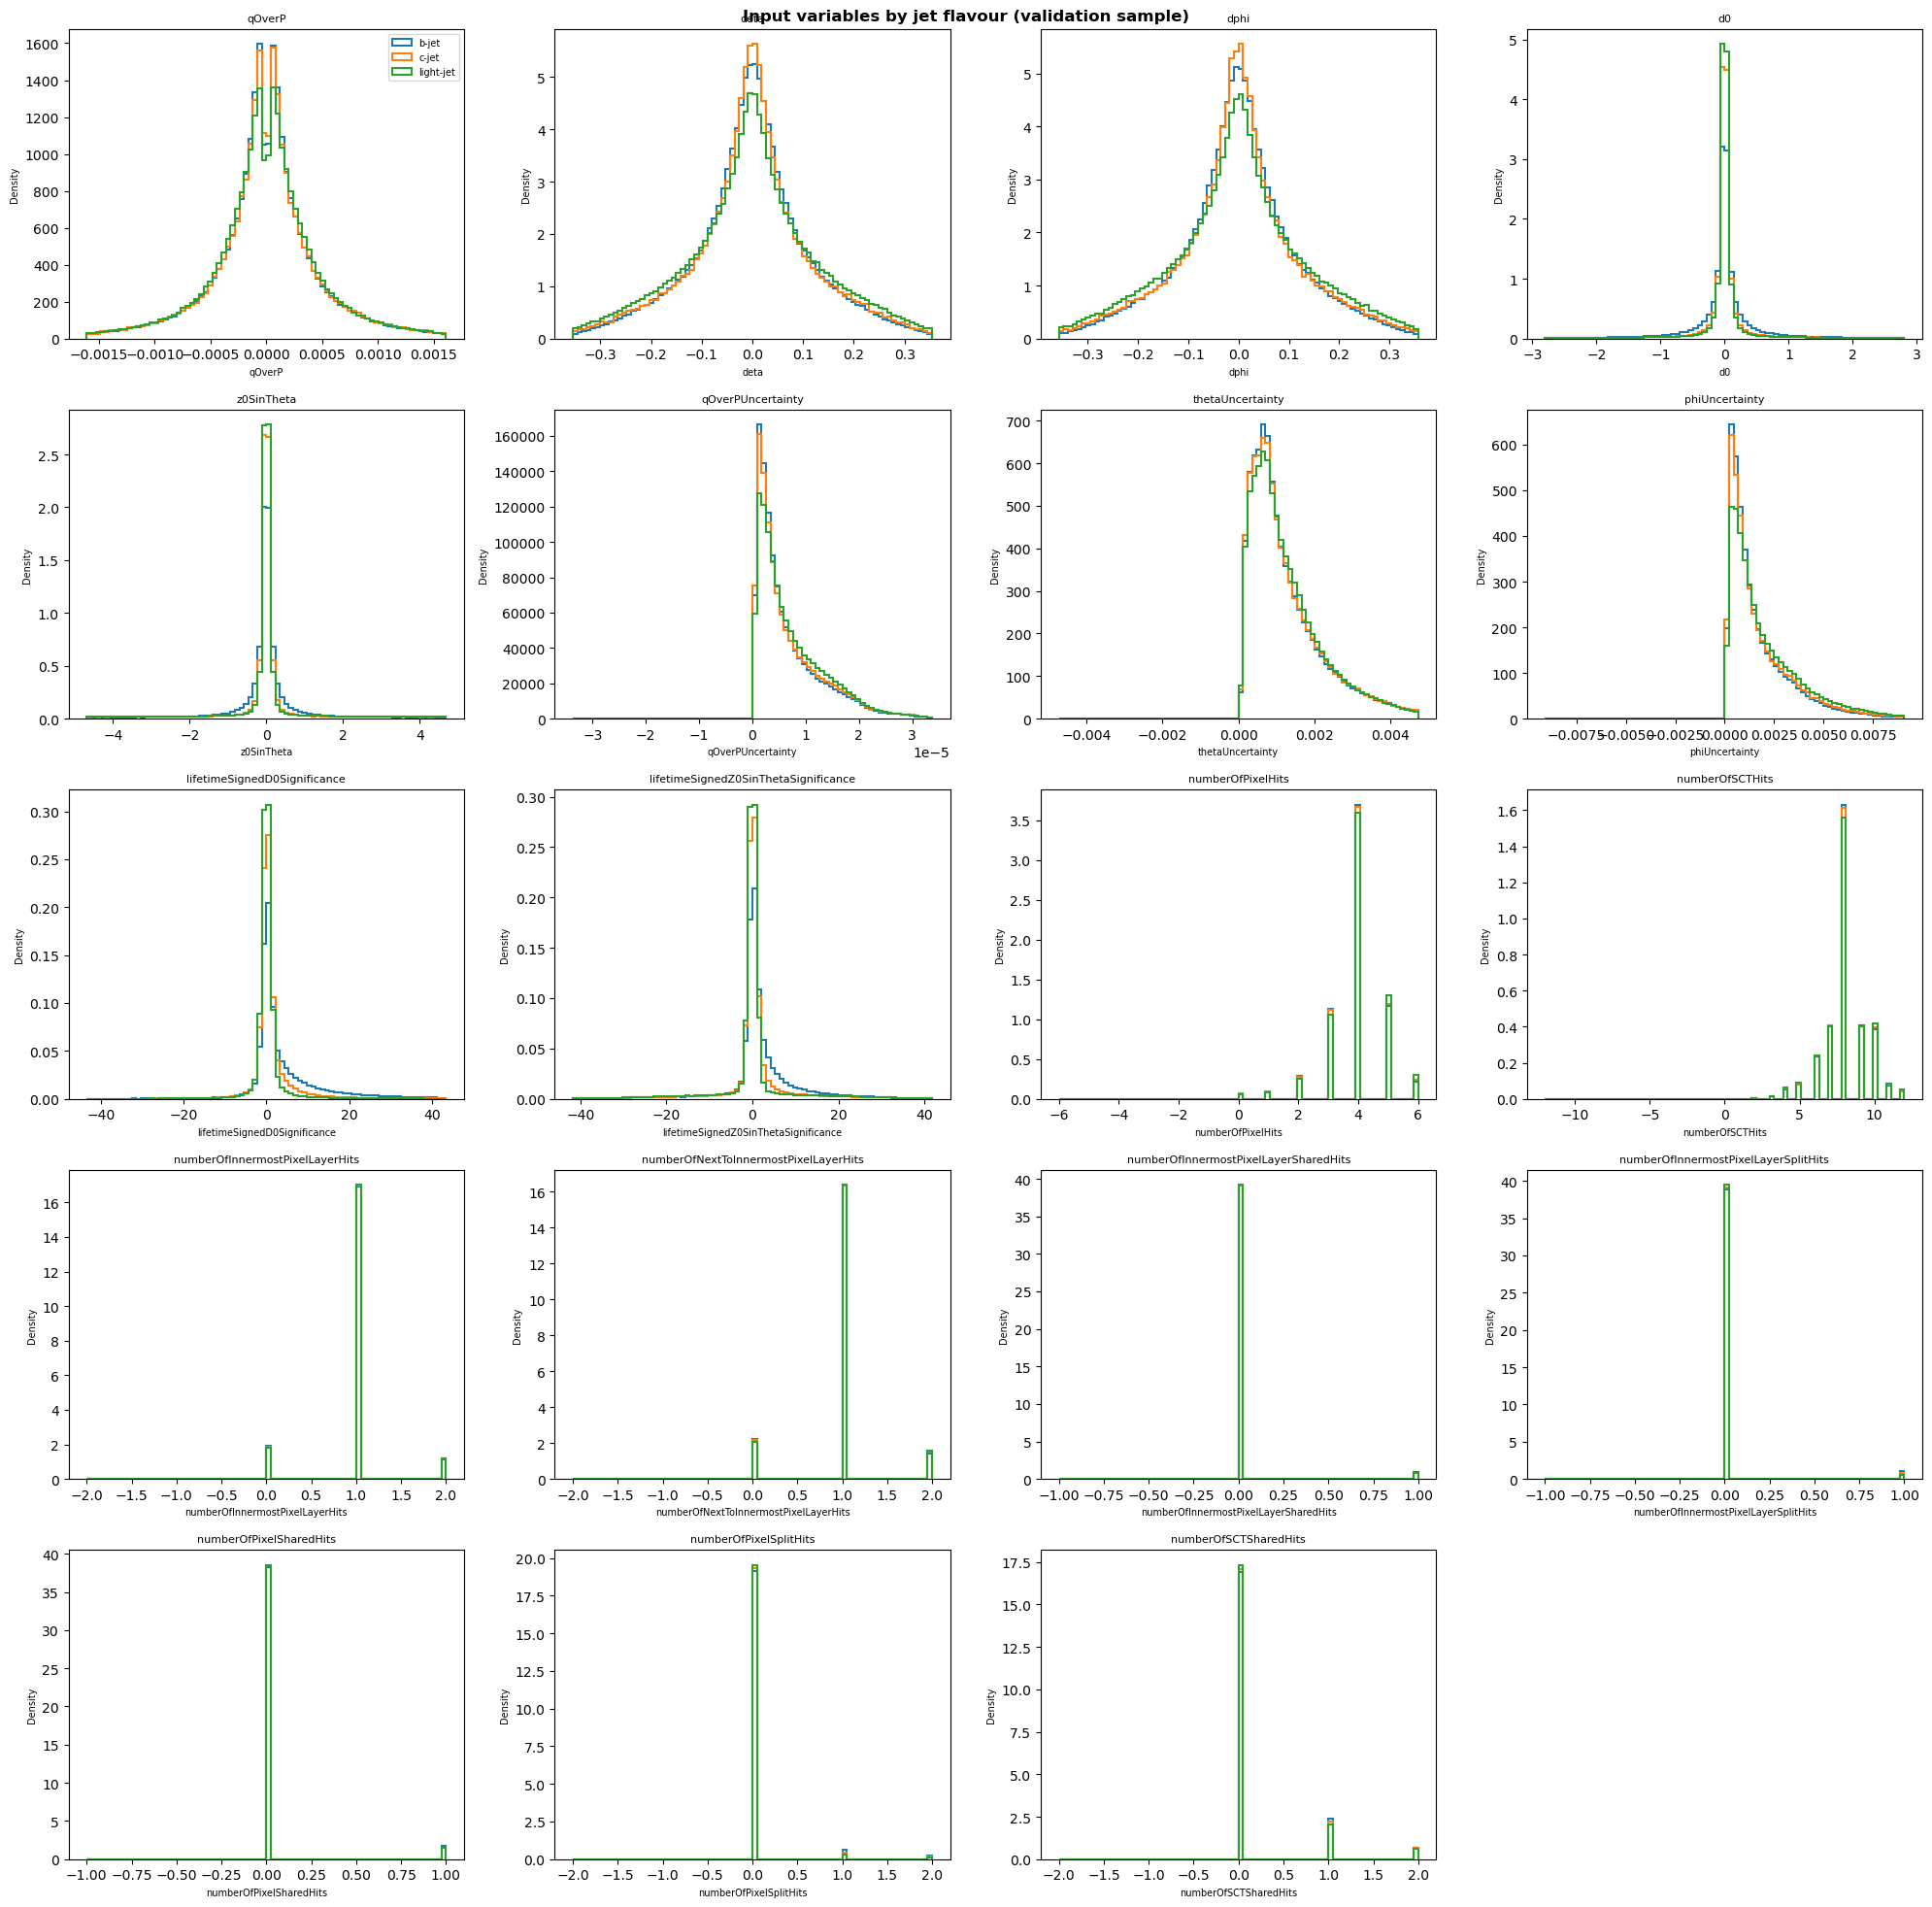

In [35]:
n_cols = min(N_FEATS, 4)
n_rows = (N_FEATS + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = np.array(axes).ravel()
fig.suptitle("Input variables by jet flavour (validation sample)", fontweight="bold")
tracks_flat = X_val.reshape(-1, N_FEATS)
labels_rep  = np.repeat(all_true, TOP_K)
nonzero     = mask_val.ravel()
for fi, fld in enumerate(TRACK_FIELDS):
    col = tracks_flat[:, fi]
    valid_col = col[nonzero]
    clip = np.percentile(np.abs(valid_col), 99) if valid_col.size else 1.0
    for cls_idx, name in enumerate(CLASS_NAMES):
        m = (labels_rep == cls_idx) & nonzero
        axes[fi].hist(col[m], bins=80, range=(-clip, clip),
                      histtype="step", label=name, color=COLOURS[name],
                      linewidth=1.5, density=True)
    axes[fi].set_title(fld, fontsize=8)
    axes[fi].set_xlabel(fld, fontsize=7)
    axes[fi].set_ylabel("Density", fontsize=7)
    if fi == 0:
        axes[fi].legend(fontsize=7)
for ax in axes[N_FEATS:]:
    ax.set_visible(False)
plt.tight_layout()
plt.savefig(PLOT_DIR + "val_input_variables.png", dpi=150, bbox_inches="tight")
print("Saved val_input_variables.png")


## Plot: track origin confusion matrix (Stage 1 — nominal inputs)

Saved val_origin_confusion.png


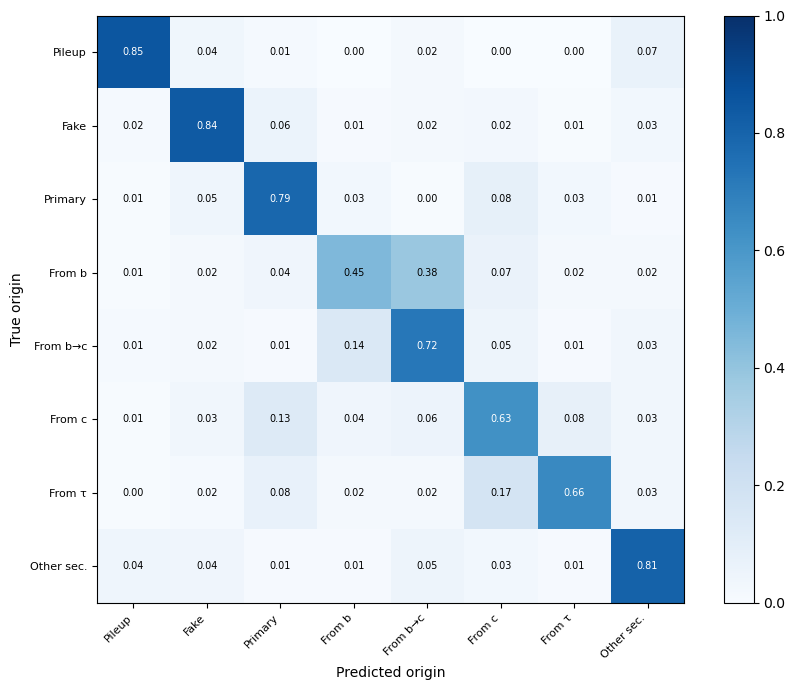

In [38]:
ORIGIN_NAMES = ["Pileup", "Fake", "Primary", "From b", "From b→c", "From c", "From τ", "Other sec."]
present      = sorted(np.unique(origin_true))
labels_pres  = [ORIGIN_NAMES[i] for i in present]

cm_orig = confusion_matrix(origin_true, origin_preds, labels=present, normalize="true")
fig, ax = plt.subplots(figsize=(9, 7))
#fig.suptitle("Track origin confusion matrix (normalised)", fontweight="bold")
im = ax.imshow(cm_orig, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(present))); ax.set_yticks(range(len(present)))
ax.set_xticklabels(labels_pres, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(labels_pres, fontsize=8)
ax.set_xlabel("Predicted origin"); ax.set_ylabel("True origin")
for i in range(len(present)):
    for j in range(len(present)):
        ax.text(j, i, f"{cm_orig[i,j]:.2f}", ha="center", va="center", fontsize=7,
                color="white" if cm_orig[i,j] > 0.5 else "black")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(PLOT_DIR + "val_origin_confusion.png", dpi=150, bbox_inches="tight")
print("Saved val_origin_confusion.png")


## Plot: confusion matrix

Saved val_confusion_matrix.png


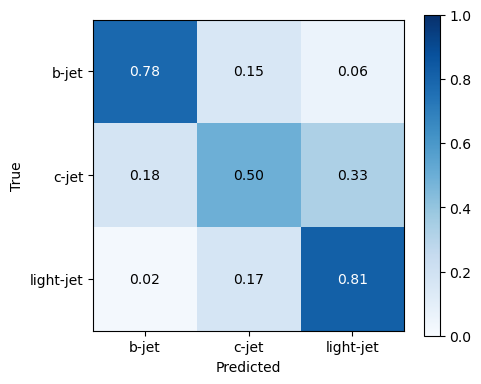

In [41]:
fig, ax = plt.subplots(figsize=(5, 4))
#fig.suptitle("Confusion matrix (normalised)", fontweight="bold")
cm = confusion_matrix(all_true, all_preds, normalize="true")
im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks([0, 1, 2]); ax.set_yticks([0, 1, 2])
ax.set_xticklabels(CLASS_NAMES); ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
for i in range(3):
    for j in range(3):
        ax.text(j, i, f"{cm[i,j]:.2f}", ha="center", va="center",
                color="white" if cm[i,j] > 0.5 else "black")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(PLOT_DIR + "val_confusion_matrix.png", dpi=150, bbox_inches="tight")
print("Saved val_confusion_matrix.png")


## Plot: output probabilities (nominal)

Saved val_output_probs_Pb_jet.png
Saved val_output_probs_Pc_jet.png
Saved val_output_probs_Plight_jet.png


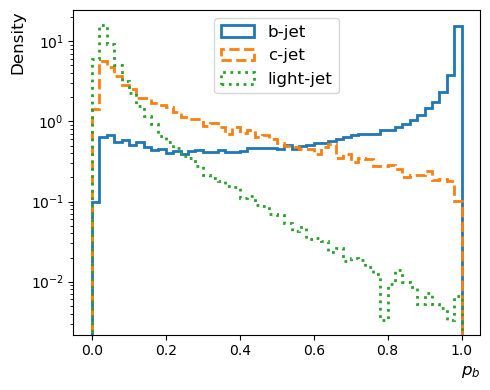

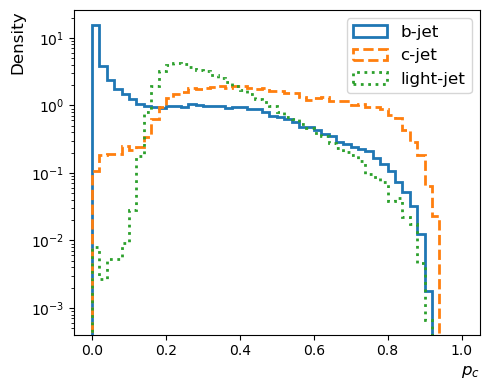

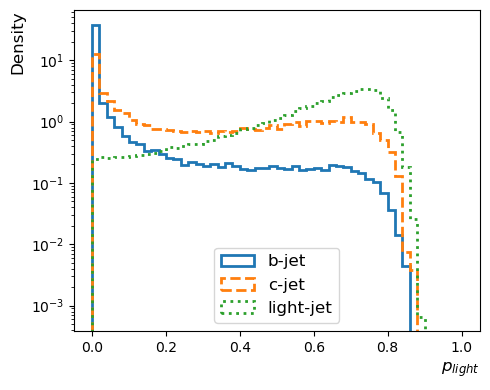

In [118]:
LINESTYLES_F = ['solid', 'dashed', 'dotted', 'dashdot']
for cls_idx, cls_name in enumerate(CLASS_NAMES):
    fig, ax = plt.subplots(figsize=(5, 4))
    for true_idx, true_name in enumerate(CLASS_NAMES):
        mask = all_true == true_idx
        ax.hist(all_probs[mask, cls_idx], bins=50, range=(0, 1), histtype="step",
                label=true_name, color=COLOURS[true_name], linewidth=2, density=True, linestyle=LINESTYLES_F[true_idx])
    #ax.set_title(f"P({cls_name})")
    ax.set_xlabel(r"$p_{" + cls_name.split('-')[0] + "}$", loc = 'right', fontsize=12)
    ax.set_ylabel("Density", loc = 'top', fontsize=12)
    ax.set_yscale("log")
    ax.legend(fontsize=12)
    plt.tight_layout()
    fname = f"val_output_probs_P{cls_name.replace('-', '_')}.png"
    plt.savefig(PLOT_DIR + fname, dpi=150, bbox_inches="tight")
    print(f"Saved {fname}")


## Plot: discriminant (nominal)

Saved val_discriminant.png


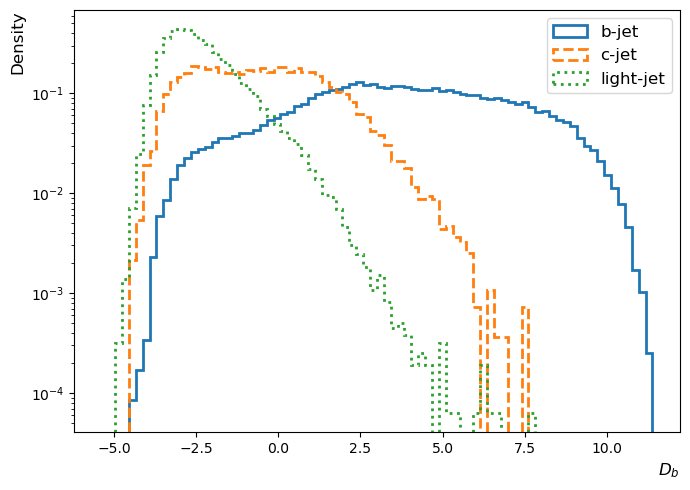

In [148]:
finite    = np.isfinite(disc)
clip_disc = np.percentile(np.abs(disc[finite]), 100)

fig, ax = plt.subplots(figsize=(7, 5))
#fig.suptitle(r"$\log(p_b\,/\,(0.2\,p_c + 0.8\,p_u))$", fontweight="bold")

for true_idx, true_name in enumerate(CLASS_NAMES):
    m = (all_true == true_idx) & finite
    ax.hist(disc[m], bins=80, range=(-clip_disc + 6, clip_disc), histtype="step",
            label=true_name, color=COLOURS[true_name], linewidth=2, density=True, linestyle=LINESTYLES_F[true_idx])
ax.set_xlabel(r"$D_{b}$", loc = 'right', fontsize=12)
ax.set_ylabel("Density", loc = 'top', fontsize=12)
ax.set_yscale("log")
ax.legend(fontsize=12)
plt.tight_layout()
plt.savefig(PLOT_DIR + "val_discriminant.png", dpi=150, bbox_inches="tight")
print("Saved val_discriminant.png")


Saved val_discriminant_post_flip.png


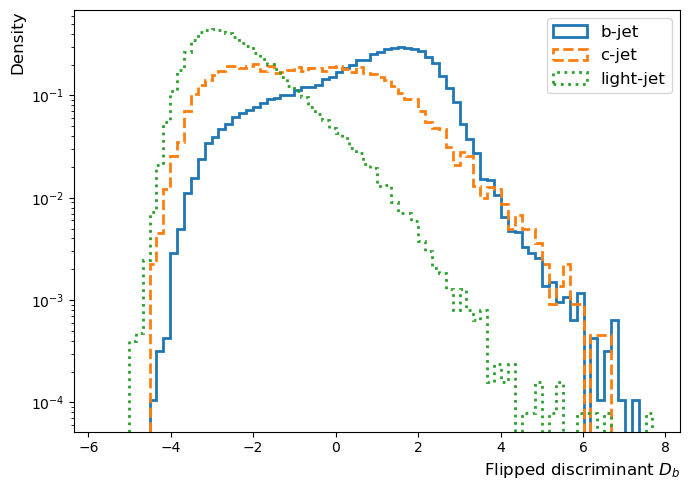

In [146]:
finite    = np.isfinite(disc)
clip_disc_flip = np.percentile(np.abs(disc_flip[finite]), 100)
fig, ax = plt.subplots(figsize=(7, 5))
#fig.suptitle(r"$\log(p_b\,/\,(0.2\,p_c + 0.8\,p_u))$", fontweight="bold")
for true_idx, true_name in enumerate(CLASS_NAMES):
    m = (all_true == true_idx) & finite
    ax.hist(disc_flip[m], bins=80, range=(-clip_disc_flip+2, clip_disc_flip), histtype="step",
            label=true_name, color=COLOURS[true_name], linewidth=2, density=True, linestyle=LINESTYLES_F[true_idx])
ax.set_xlabel(r"Flipped discriminant $D_{b}$", loc = 'right', fontsize=12)
ax.set_ylabel("Density", loc = 'top', fontsize=12)
ax.set_yscale("log")
ax.legend(fontsize=12)
plt.tight_layout()
plt.savefig(PLOT_DIR + "val_discriminant_post_flip.png", dpi=150, bbox_inches="tight")
print("Saved val_discriminant_post_flip.png")

## Plot: ROC curves (nominal)

Saved val_roc.png


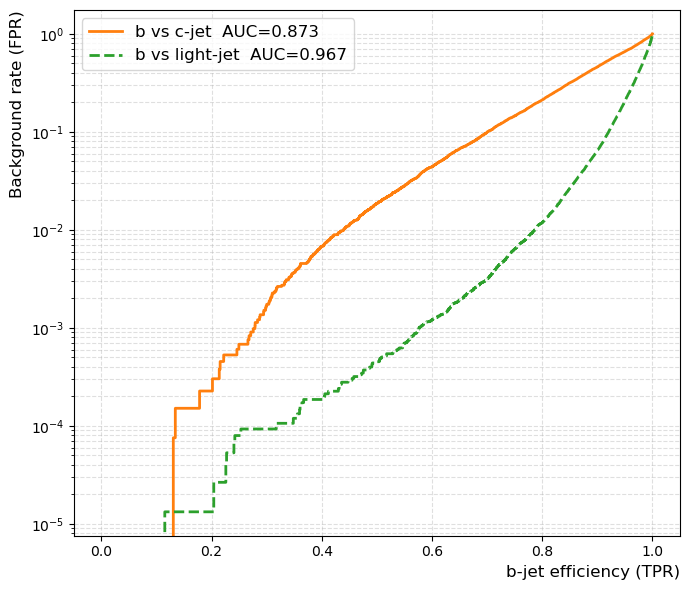

In [124]:
fig, ax = plt.subplots(figsize=(7, 6))
BKG_COLOURS = {"c-jet": COLOURS["c-jet"], "light-jet": COLOURS["light-jet"]}

for bkg_idx, bkg_name in [(1, "c-jet"), (2, "light-jet")]:
    m      = (all_true == 0) | (all_true == bkg_idx)
    scores = (all_true[m] == 0).astype(int)
    score  = disc[m]
    finite = np.isfinite(score)
    fpr, tpr, _ = roc_curve(scores[finite], score[finite])
    ax.plot(tpr, fpr, color=BKG_COLOURS[bkg_name], linewidth=2,
            label=f"b vs {bkg_name}  AUC={auc(fpr, tpr):.3f}", linestyle=LINESTYLES_F[bkg_idx-1])
ax.set_xlabel("b-jet efficiency (TPR)", loc = 'right', fontsize=12)
ax.set_ylabel("Background rate (FPR)", loc = 'top', fontsize=12)
#ax.set_title("ROC curves (nominal): b vs c / b vs light")
ax.set_yscale("log")
ax.legend(fontsize=12)
ax.grid(True, which="both", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(PLOT_DIR + "val_roc.png", dpi=150, bbox_inches="tight")
print("Saved val_roc.png")


## Plot: discriminant overlay — nominal vs flipped

/var/folders/1f/fh3hss417dlc_9pw9wv1h3nc0000gq/T/ipykernel_53682/1721353133.py:38: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved val_discriminant_overlay_b_jet.png
Saved val_discriminant_overlay_c_jet.png
Saved val_discriminant_overlay_light_jet.png


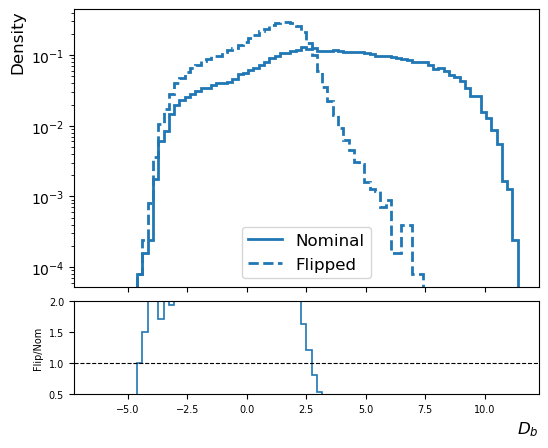

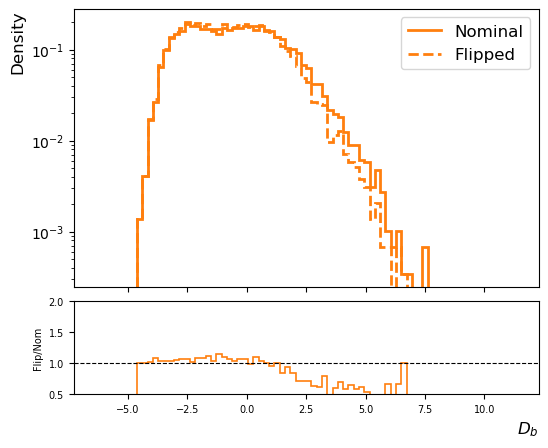

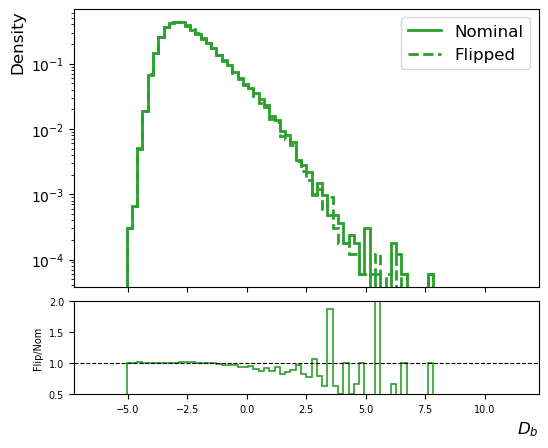

In [142]:
all_disc_cat = np.concatenate([disc, disc_flip])
finite_all   = np.isfinite(all_disc_cat)
clip_disc    = np.percentile(np.abs(all_disc_cat[finite_all]), 100)
disc_bins    = np.linspace(-clip_disc + 5, clip_disc, 81)

for cls_idx, cls_name in enumerate(CLASS_NAMES):
    fig = plt.figure(figsize=(6, 5))
    gs = fig.add_gridspec(2, 1, hspace=0.08, height_ratios=[3, 1])
    ax_main  = fig.add_subplot(gs[0])
    ax_ratio = fig.add_subplot(gs[1], sharex=ax_main)

    counts = {}
    for label, probs_c, d in CASES:
        finite = np.isfinite(d)
        m      = (all_true == cls_idx) & finite
        h, _   = np.histogram(d[m], bins=disc_bins, density=True)
        counts[label] = h
        ax_main.stairs(h, disc_bins, color=COLOURS[cls_name],
                       linestyle=LINESTYLES[label], linewidth=2, label=label)

    #ax_main.set_title(f"True {cls_name}")
    ax_main.set_ylabel("Density", loc = 'top', fontsize=12)
    ax_main.set_yscale("log")
    ax_main.legend(fontsize=12)
    plt.setp(ax_main.get_xticklabels(), visible=False)

    h_nom, h_flip = counts["Nominal"], counts["Flipped"]
    valid_bin = h_nom > 0
    ratio     = np.where(valid_bin, h_flip / np.where(valid_bin, h_nom, 1), np.nan)
    ax_ratio.stairs(ratio, disc_bins, color=COLOURS[cls_name], linewidth=1.2)
    ax_ratio.axhline(1.0, color="black", linewidth=0.8, linestyle="--")
    ax_ratio.set_ylim(0.5, 2.0)
    ax_ratio.set_ylabel("Flip/Nom", fontsize=7)
    ax_ratio.yaxis.set_major_locator(plt.MultipleLocator(0.5))
    ax_ratio.tick_params(labelsize=7)
    ax_ratio.set_xlabel(r"$D_{b}$", loc = 'right', fontsize=12)

    plt.tight_layout()
    fname = f"val_discriminant_overlay_{cls_name.replace('-', '_')}.png"
    plt.savefig(PLOT_DIR + fname, dpi=150, bbox_inches="tight")
    print(f"Saved {fname}")


## Plot: 2D scatter — nominal vs flipped discriminant (light jets)

Saved val_disc_scatter_light.png


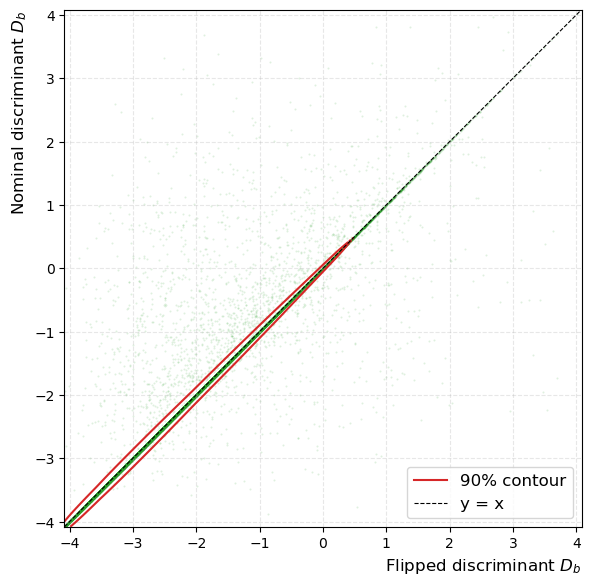

In [140]:
light_mask = (all_true == 2) & np.isfinite(disc) & np.isfinite(disc_flip)
x_scatter  = disc_flip[light_mask]   # flipped
y_scatter  = disc[light_mask]        # nominal

clip_x = np.percentile(np.abs(x_scatter), 99)
clip_y = np.percentile(np.abs(y_scatter), 99)
lim    = max(clip_x, clip_y)

MAX_PTS = 50_000
if len(x_scatter) > MAX_PTS:
    rng_sc      = np.random.default_rng(0)
    sel         = rng_sc.choice(len(x_scatter), MAX_PTS, replace=False)
    x_sc, y_sc = x_scatter[sel], y_scatter[sel]
else:
    x_sc, y_sc = x_scatter, y_scatter

from scipy.stats import gaussian_kde

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(x_sc, y_sc, s=2, alpha=0.15, color=COLOURS["light-jet"], linewidths=0)

_kde      = gaussian_kde(np.vstack([x_sc, y_sc]))
_grid_pts = 200
_gx       = np.linspace(-lim, lim, _grid_pts)
_gy       = np.linspace(-lim, lim, _grid_pts)
_XX, _YY  = np.meshgrid(_gx, _gy)
_Z        = _kde(np.vstack([_XX.ravel(), _YY.ravel()])).reshape(_grid_pts, _grid_pts)
_z_flat   = np.sort(_Z.ravel())[::-1]
_cumsum   = np.cumsum(_z_flat) / _z_flat.sum()
_threshold = _z_flat[np.searchsorted(_cumsum, 0.90)]
ax.contour(_XX, _YY, _Z, levels=[_threshold], colors=["#d62728"], linewidths=1.5, linestyles="-")
ax.plot([], [], color="#d62728", linewidth=1.5, label="90% contour")

ax.axline((0, 0), slope=1, color="black", linewidth=0.8, linestyle="--", label="y = x")
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_xlabel(r"Flipped discriminant $D_{b}$", loc = 'right', fontsize=12)
ax.set_ylabel(r"Nominal discriminant $D_{b}$", loc = 'top', fontsize=12)
#ax.set_title("Light jets: nominal vs flipped discriminant", fontweight="bold")
ax.legend(fontsize=12)
ax.set_aspect("equal")
ax.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.savefig(PLOT_DIR + "val_disc_scatter_light.png", dpi=150, bbox_inches="tight")
print("Saved val_disc_scatter_light.png")


## Plot: zoom-in tail plots (5%, 1%, 0.1%)

/var/folders/1f/fh3hss417dlc_9pw9wv1h3nc0000gq/T/ipykernel_53682/1478073671.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved val_disc_tail_zoom_light.png
Saved val_disc_tail_zoom_light_1pct.png
Saved val_disc_tail_zoom_light_01pct.png


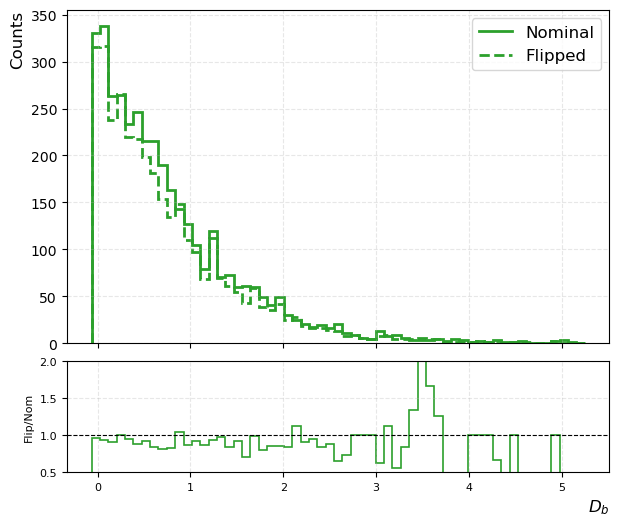

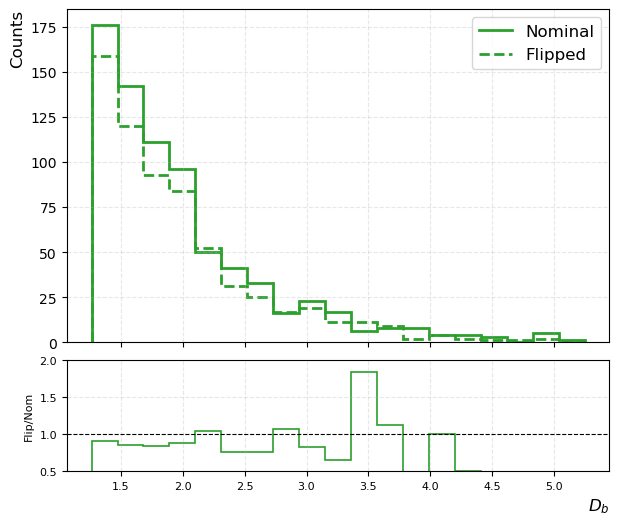

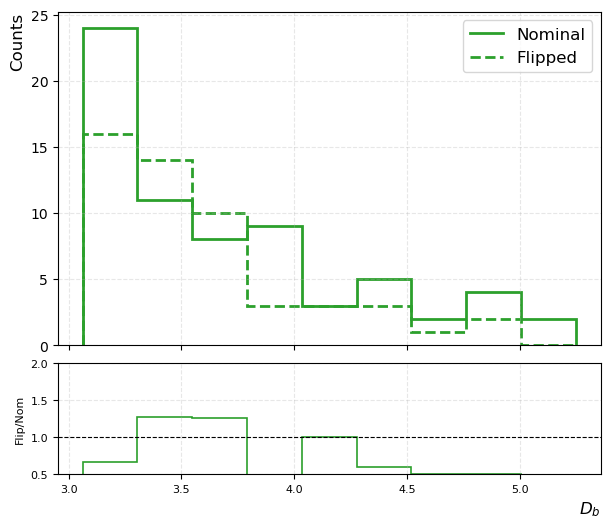

In [158]:
light_nom  = disc[light_mask]
light_flip = disc_flip[light_mask]

for pct, pct_label, fname, n_bins in [
    (95,   "top 5%",   "val_disc_tail_zoom_light.png",      60),
    (99,   "top 1%",   "val_disc_tail_zoom_light_1pct.png", 20),
    (99.9, "top 0.1%", "val_disc_tail_zoom_light_01pct.png", 10),
]:
    tail_lo   = np.percentile(light_nom, pct)
    tail_hi   = max(np.percentile(light_nom, 99.99), np.percentile(light_flip, 99.99))
    tail_bins = np.linspace(tail_lo, tail_hi, n_bins)

    fig = plt.figure(figsize=(7, 6))
    gs = fig.add_gridspec(2, 1, hspace=0.08, height_ratios=[3, 1])
    ax_main  = fig.add_subplot(gs[0])
    ax_ratio = fig.add_subplot(gs[1], sharex=ax_main)

    counts_t = {}
    for d_arr, label, ls in [
        (light_nom,  "Nominal", "-"),
        (light_flip, "Flipped", "--"),
    ]:
        h, _ = np.histogram(d_arr, bins=tail_bins)
        counts_t[label] = h
        ax_main.stairs(h, tail_bins, linestyle=ls, linewidth=2,
                       color=COLOURS["light-jet"], label=label,
                       alpha=(1.0 if ls == "-" else 1.0))

    #ax_main.set_title(f"Light jets — high-tail zoom ({pct_label}): nominal vs flipped")
    ax_main.set_ylabel("Counts", loc = 'top', fontsize=12)
    ax_main.legend(fontsize=12)
    ax_main.grid(True, linestyle="--", alpha=0.3)
    plt.setp(ax_main.get_xticklabels(), visible=False)

    h_nom_t  = counts_t["Nominal"]
    h_flip_t = counts_t["Flipped"]
    valid_t  = h_nom_t > 0
    ratio_t  = np.where(valid_t, h_flip_t / np.where(valid_t, h_nom_t, 1), np.nan)
    ax_ratio.stairs(ratio_t, tail_bins, color=COLOURS["light-jet"], linewidth=1.2)
    ax_ratio.axhline(1.0, color="black", linewidth=0.8, linestyle="--")
    ax_ratio.set_ylim(0.5, 2.0)
    ax_ratio.set_ylabel("Flip/Nom", fontsize=8)
    ax_ratio.tick_params(labelsize=8)
    ax_ratio.grid(True, linestyle="--", alpha=0.3)
    ax_ratio.set_xlabel(r"$D_{b}$", loc = 'right', fontsize=12)
    ax_ratio.yaxis.set_major_locator(plt.MultipleLocator(0.5))
    plt.tight_layout()
    plt.savefig(PLOT_DIR + fname, dpi=150, bbox_inches="tight")
    print(f"Saved {fname}")


## Plot: probability overlay — nominal vs flipped

/var/folders/1f/fh3hss417dlc_9pw9wv1h3nc0000gq/T/ipykernel_53682/3521734843.py:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved val_prob_overlay_true_b_jet_Pb_jet.png
Saved val_prob_overlay_true_b_jet_Pc_jet.png
Saved val_prob_overlay_true_b_jet_Plight_jet.png
Saved val_prob_overlay_true_c_jet_Pb_jet.png
Saved val_prob_overlay_true_c_jet_Pc_jet.png
Saved val_prob_overlay_true_c_jet_Plight_jet.png
Saved val_prob_overlay_true_light_jet_Pb_jet.png
Saved val_prob_overlay_true_light_jet_Pc_jet.png
Saved val_prob_overlay_true_light_jet_Plight_jet.png


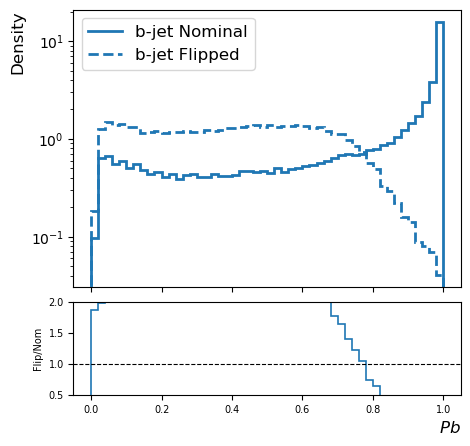

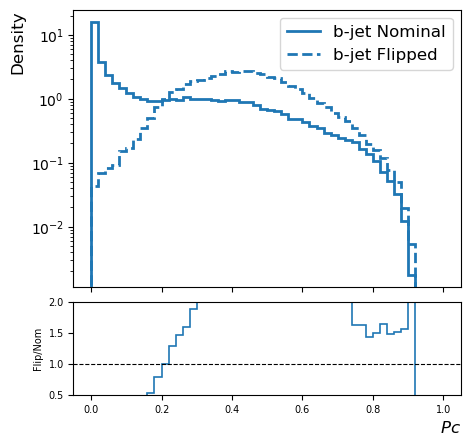

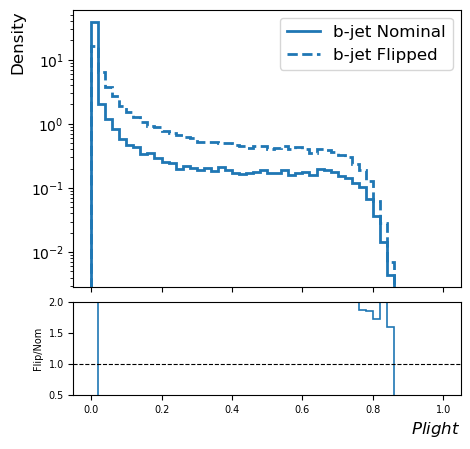

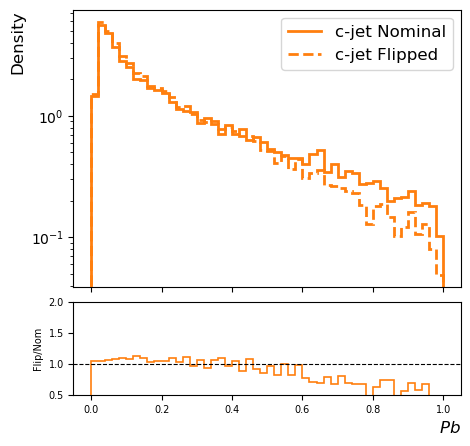

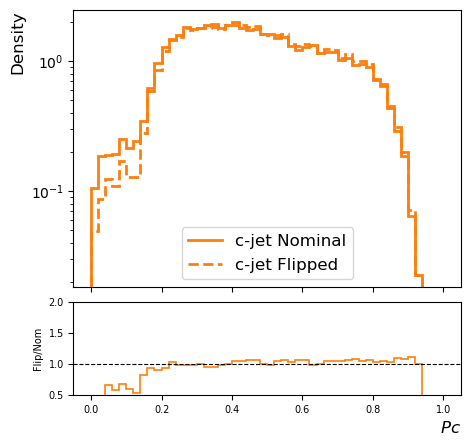

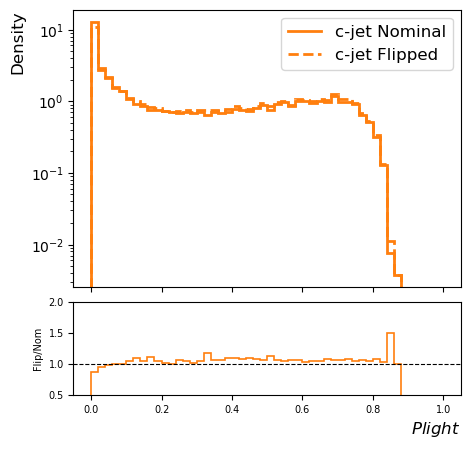

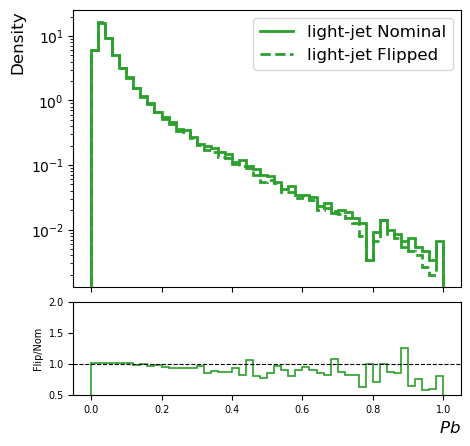

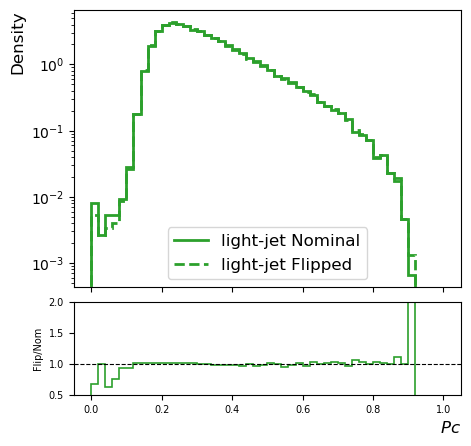

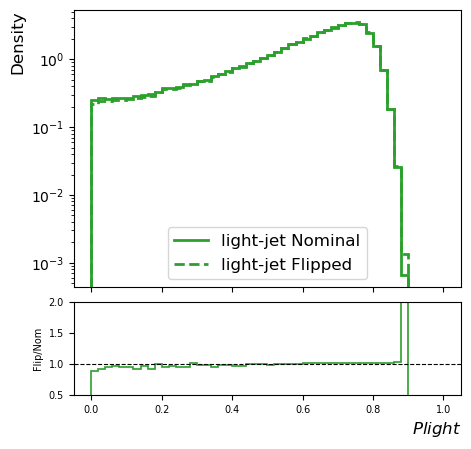

In [170]:
BINS      = 50
bin_edges = np.linspace(0, 1, BINS + 1)

for true_idx, true_name in enumerate(CLASS_NAMES):
    for cls_idx, cls_name in enumerate(CLASS_NAMES):
        fig = plt.figure(figsize=(5, 5))
        gs = fig.add_gridspec(2, 1, hspace=0.08, height_ratios=[3, 1])
        ax_main  = fig.add_subplot(gs[0])
        ax_ratio = fig.add_subplot(gs[1], sharex=ax_main)

        counts = {}
        for label, probs_c, _ in CASES:
            m = all_true == true_idx
            h, _ = np.histogram(probs_c[m, cls_idx], bins=bin_edges, density=True)
            counts[label] = h
            ax_main.stairs(h, bin_edges, color=COLOURS[true_name],
                           linestyle=LINESTYLES[label], linewidth=2, label= true_name + " " + label)

        h_nom_p, h_flip_p = counts["Nominal"], counts["Flipped"]
        valid_bin = h_nom_p > 0
        ratio     = np.where(valid_bin, h_flip_p / np.where(valid_bin, h_nom_p, 1), np.nan)
        ax_ratio.stairs(ratio, bin_edges, color=COLOURS[true_name], linewidth=1.2)
        ax_ratio.axhline(1.0, color="black", linewidth=0.8, linestyle="--")
        ax_ratio.set_ylim(0.5, 2.0)
        ax_ratio.set_ylabel("Flip/Nom", fontsize=7)
        ax_ratio.yaxis.set_major_locator(plt.MultipleLocator(0.5))
        ax_ratio.tick_params(labelsize=7)
        ax_ratio.set_xlabel(r"$P" + cls_name.split('-')[0] +  "$", loc = 'right', fontsize=12)

        #ax_main.set_title(f"True {true_name} — P({cls_name})", fontsize=9)
        ax_main.set_ylabel("Density", loc = 'top', fontsize=12)
        ax_main.set_yscale("log")
        ax_main.legend(fontsize=12)
        plt.setp(ax_main.get_xticklabels(), visible=False)

        plt.tight_layout()
        fname = f"val_prob_overlay_true_{true_name.replace('-', '_')}_P{cls_name.replace('-', '_')}.png"
        plt.savefig(PLOT_DIR + fname, dpi=150, bbox_inches="tight")
        print(f"Saved {fname}")


## Plot: ROC overlay — nominal vs flipped

Saved val_roc_overlay.png


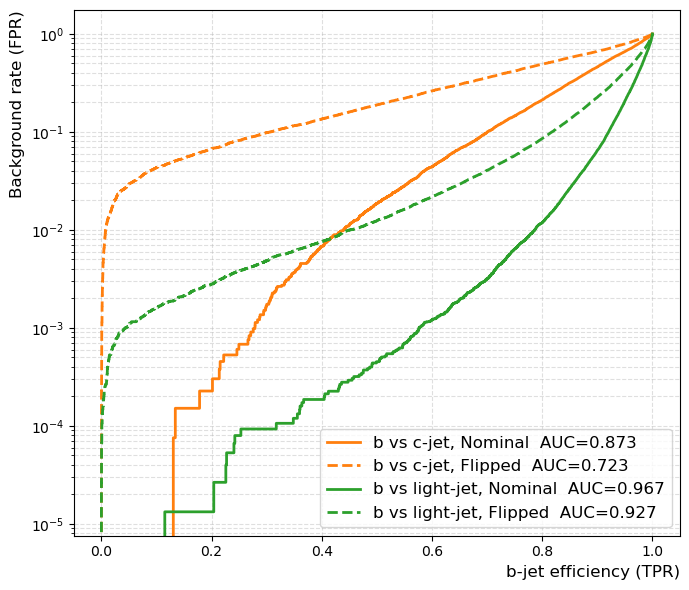

In [174]:
fig, ax = plt.subplots(figsize=(7, 6))
BKG_COLOURS = {"c-jet": COLOURS["c-jet"], "light-jet": COLOURS["light-jet"]}
for bkg_idx, bkg_name in [(1, "c-jet"), (2, "light-jet")]:
    for label, probs_c, d in CASES:
        m      = (all_true == 0) | (all_true == bkg_idx)
        scores = (all_true[m] == 0).astype(int)
        score  = d[m]
        finite = np.isfinite(score)
        fpr, tpr, _ = roc_curve(scores[finite], score[finite])
        ax.plot(tpr, fpr, color=BKG_COLOURS[bkg_name], linewidth=2,
                label=f"b vs {bkg_name}, {label}  AUC={auc(fpr, tpr):.3f}",
                linestyle=LINESTYLES[label])
ax.set_xlabel("b-jet efficiency (TPR)", loc = 'right', fontsize=12)
ax.set_ylabel("Background rate (FPR)" , loc = 'top', fontsize=12)
#ax.set_title("ROC curves: b vs c / b vs light, nominal vs flipped")
ax.set_yscale("log")
ax.legend(fontsize=12)
ax.grid(True, which="both", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(PLOT_DIR + "val_roc_overlay.png", dpi=150, bbox_inches="tight")
print("Saved val_roc_overlay.png")
